Saving housing.csv to housing (1).csv


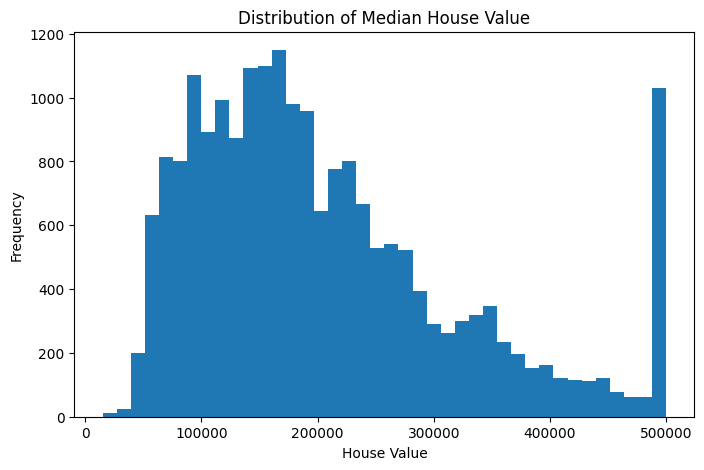

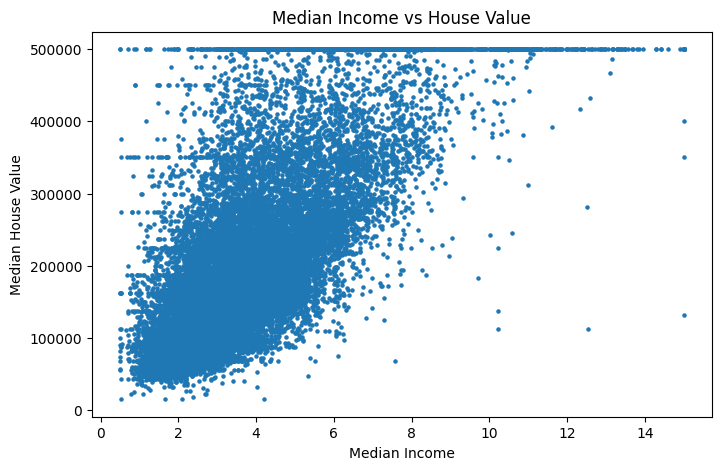

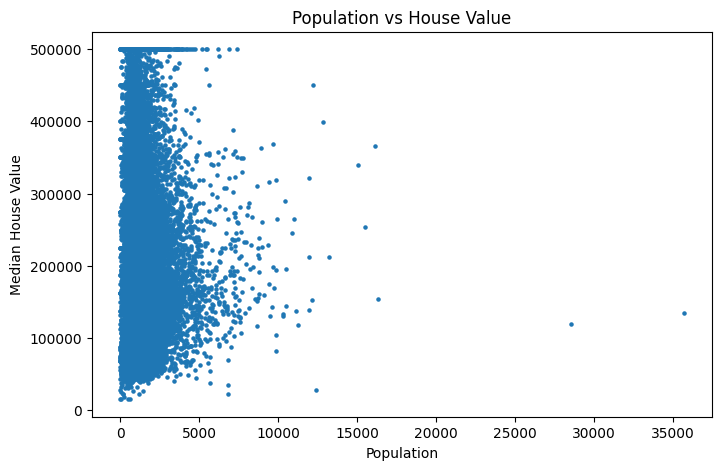

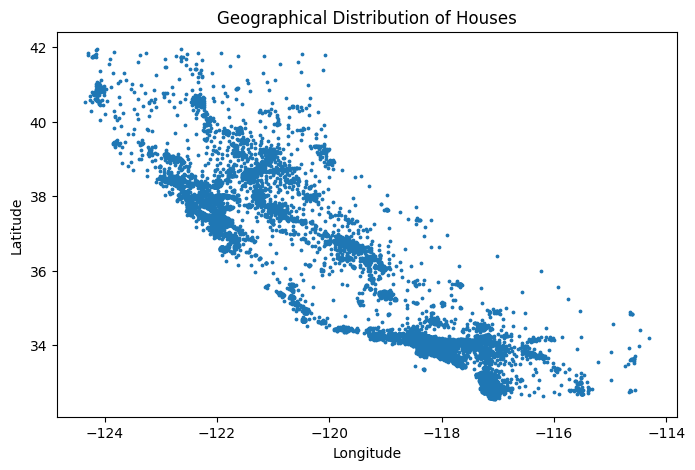

      Model Evaluation Results
Mean Squared Error: 4932807487.094359
R² Score: 0.6392875849855844


In [3]:
# ==========================================================
#  Task 3: California Housing Price Prediction
# ==========================================================

import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ----------------------------------------------------------
# 1. Upload Dataset
# ----------------------------------------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]   # Get the uploaded filename
df = pd.read_csv(filename)

# ----------------------------------------------------------
# 2. Data Cleaning
# ----------------------------------------------------------
# Remove any missing values
df = df.dropna()

# Convert categorical feature into numerical form
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# ----------------------------------------------------------
# 3. Exploratory Data Analysis (PLOTS)
# ----------------------------------------------------------

# 👉 Plot 1: Distribution of House Prices
plt.figure(figsize=(8,5))
plt.hist(df["median_house_value"], bins=40)
plt.title("Distribution of Median House Value")
plt.xlabel("House Value")
plt.ylabel("Frequency")
plt.show()

# Explanation:
# This histogram shows how house prices are distributed across California.
# It helps identify whether prices are skewed toward low or high values.

# 👉 Plot 2: Median Income vs House Value
plt.figure(figsize=(8,5))
plt.scatter(df["median_income"], df["median_house_value"], s=5)
plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

# Explanation:
# This scatter plot shows a clear positive relationship:
# Higher income areas tend to have higher house prices.

# 👉 Plot 3: Population vs House Value
plt.figure(figsize=(8,5))
plt.scatter(df["population"], df["median_house_value"], s=5)
plt.title("Population vs House Value")
plt.xlabel("Population")
plt.ylabel("Median House Value")
plt.show()

# Explanation:
# This plot shows whether highly populated areas have higher or lower house values.

# 👉 Plot 4: Long/Lat Location Plot
plt.figure(figsize=(8,5))
plt.scatter(df["longitude"], df["latitude"], s=3)
plt.title("Geographical Distribution of Houses")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Explanation:
# This plot visualizes California geographically.
# Houses cluster along the coast where most people live.

# ----------------------------------------------------------
# 4. Selecting Required Features
# ----------------------------------------------------------
features = [
    "longitude",
    "latitude",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
] + [col for col in df.columns if col.startswith("ocean_proximity_")]

X = df[features]
y = df["median_house_value"]

# ----------------------------------------------------------
# 5. Split the Dataset
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------
# 6. Scale Numerical Features
# ----------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------------------------------------
# 7. Train the Model
# ----------------------------------------------------------
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# ----------------------------------------------------------
# 8. Evaluate the Model
# ----------------------------------------------------------
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("============================================")
print("      Model Evaluation Results")
print("============================================")
print("Mean Squared Error:", mse)
print("R² Score:", r2)
print("============================================")
